INFO:__main__:Calculating TDA Features for KS...


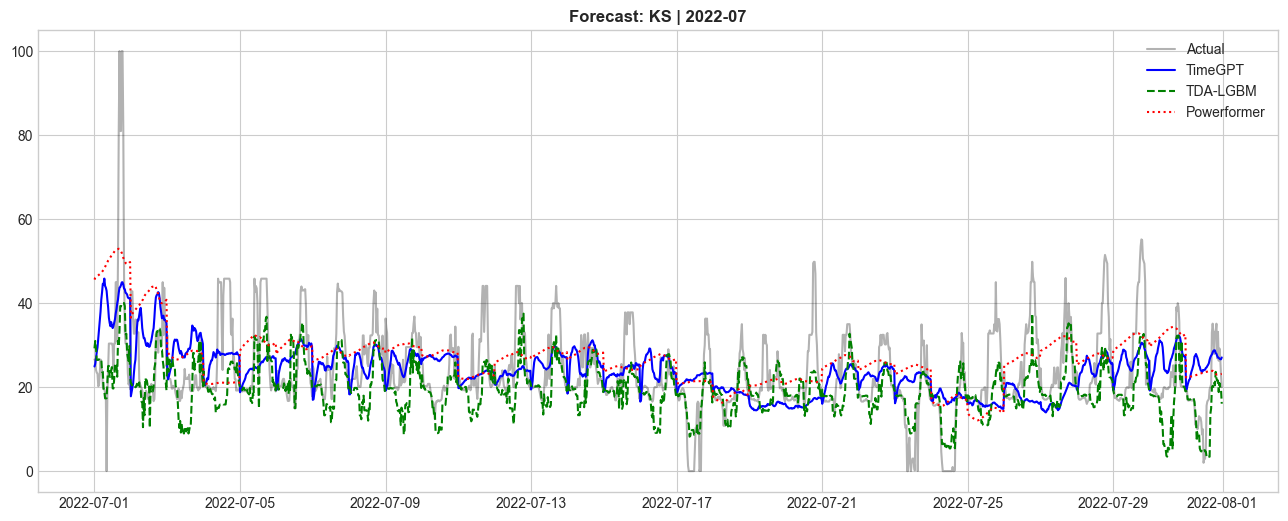

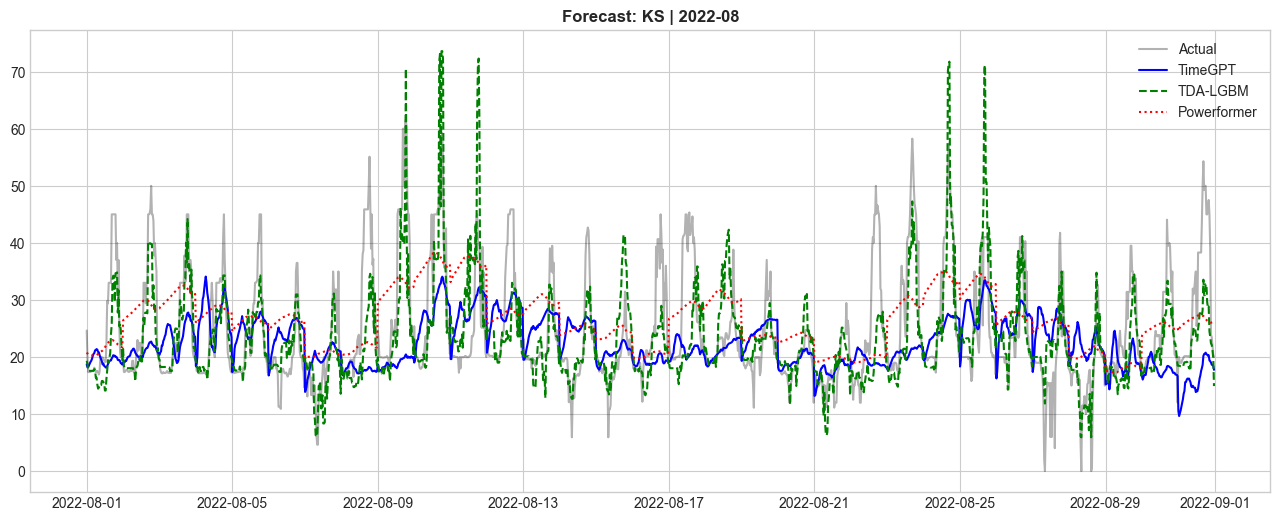

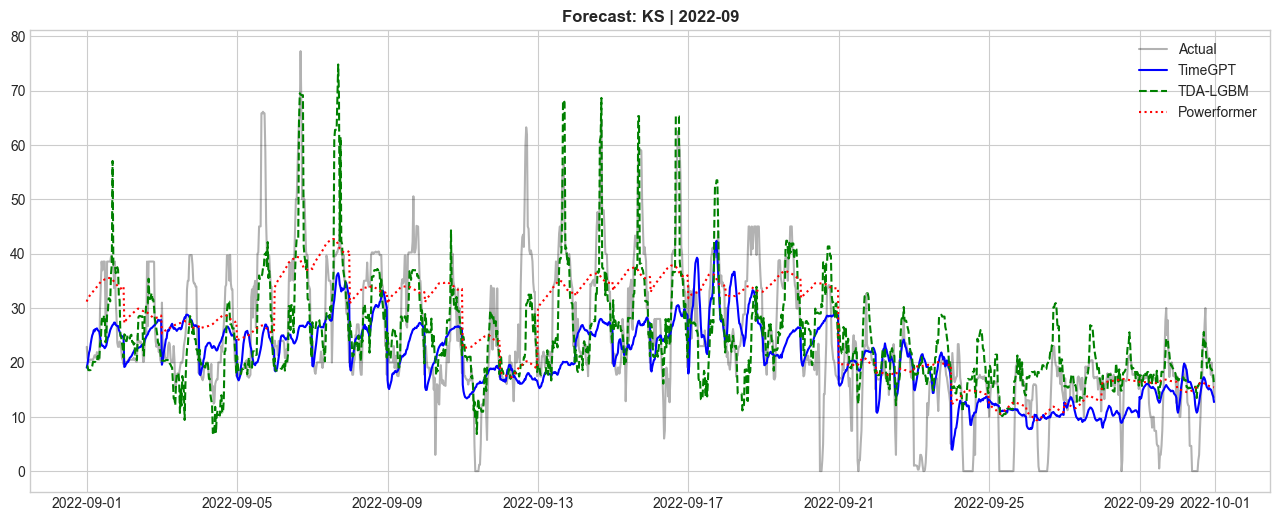

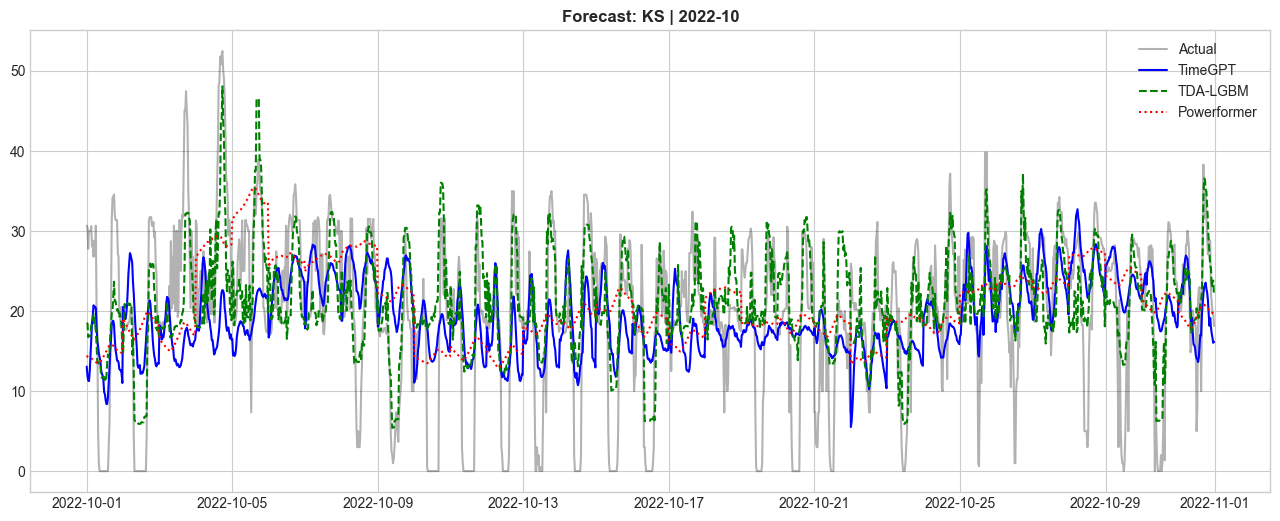

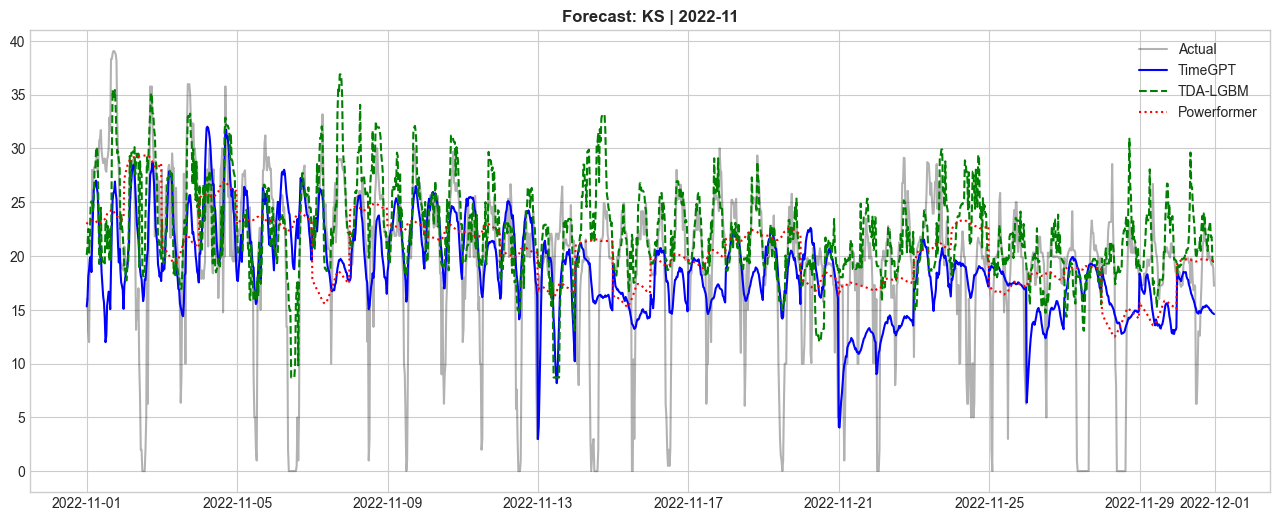

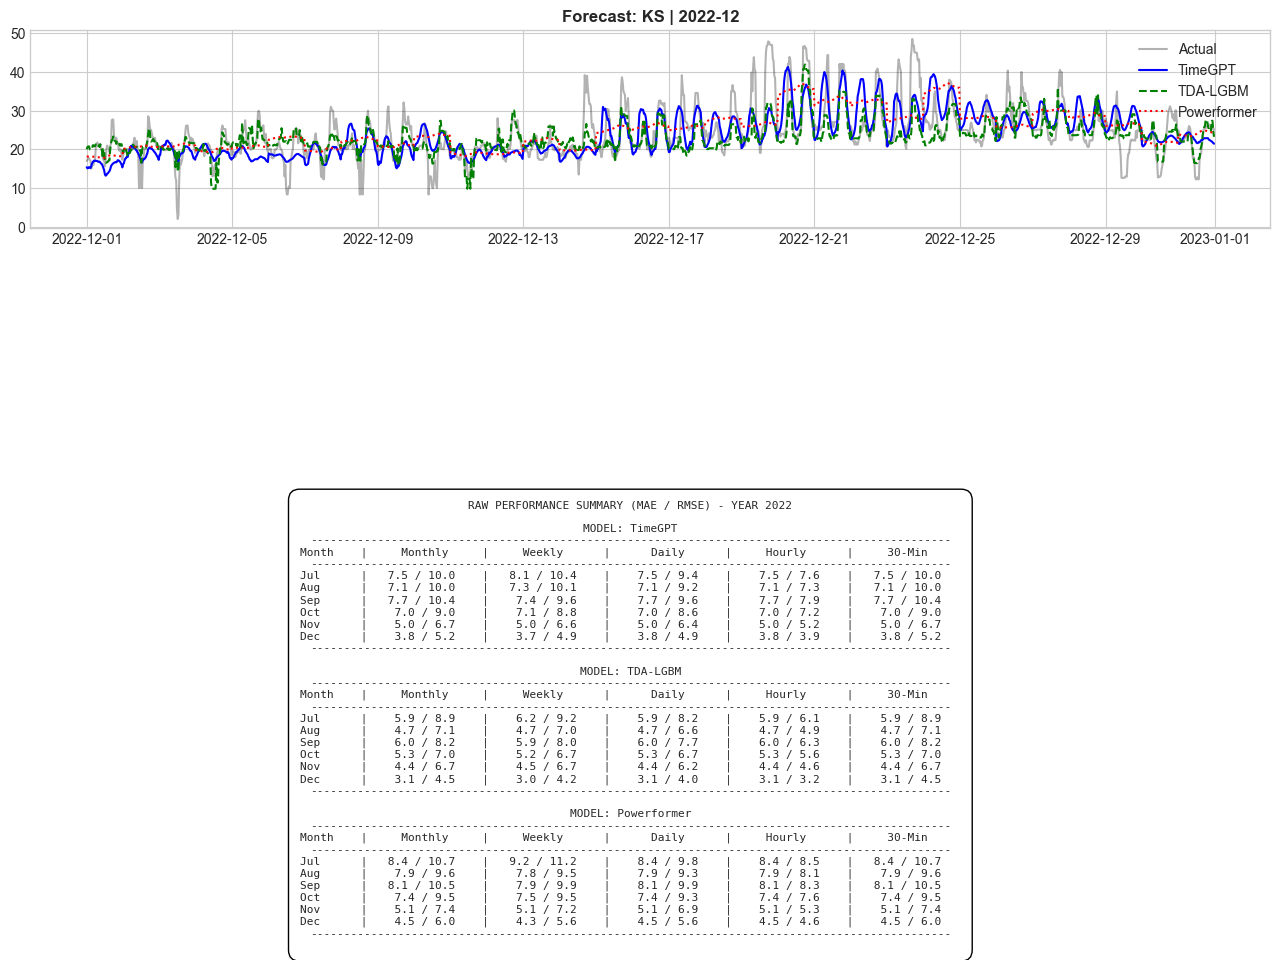

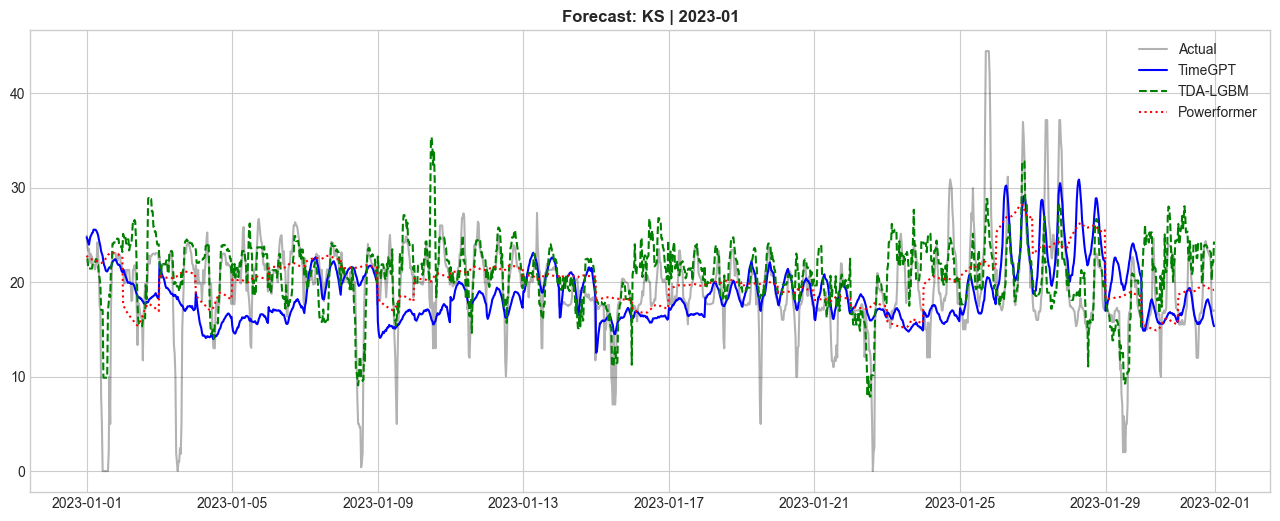

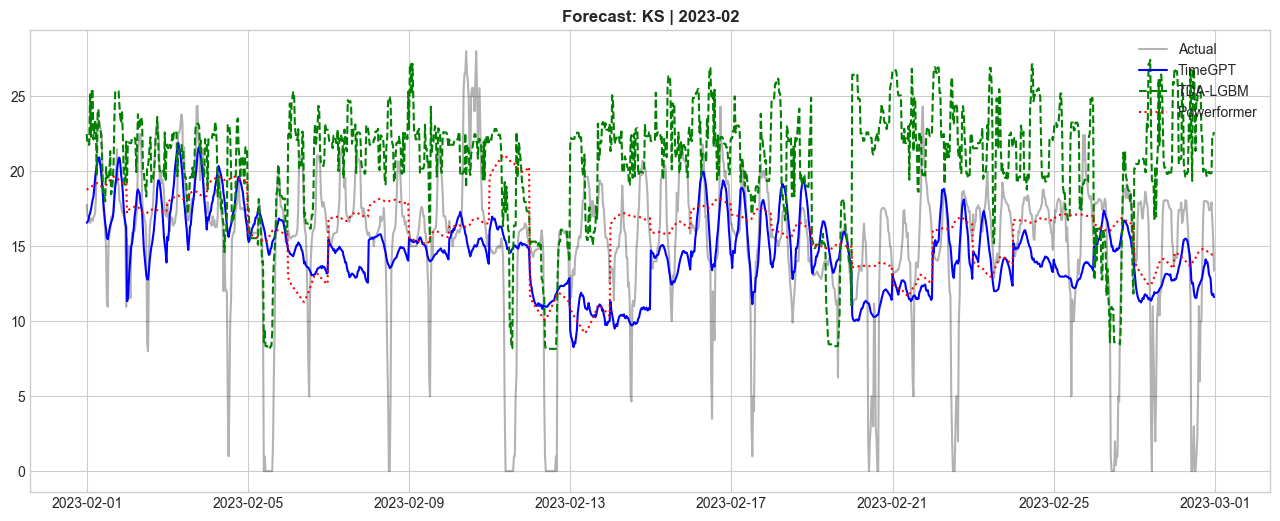

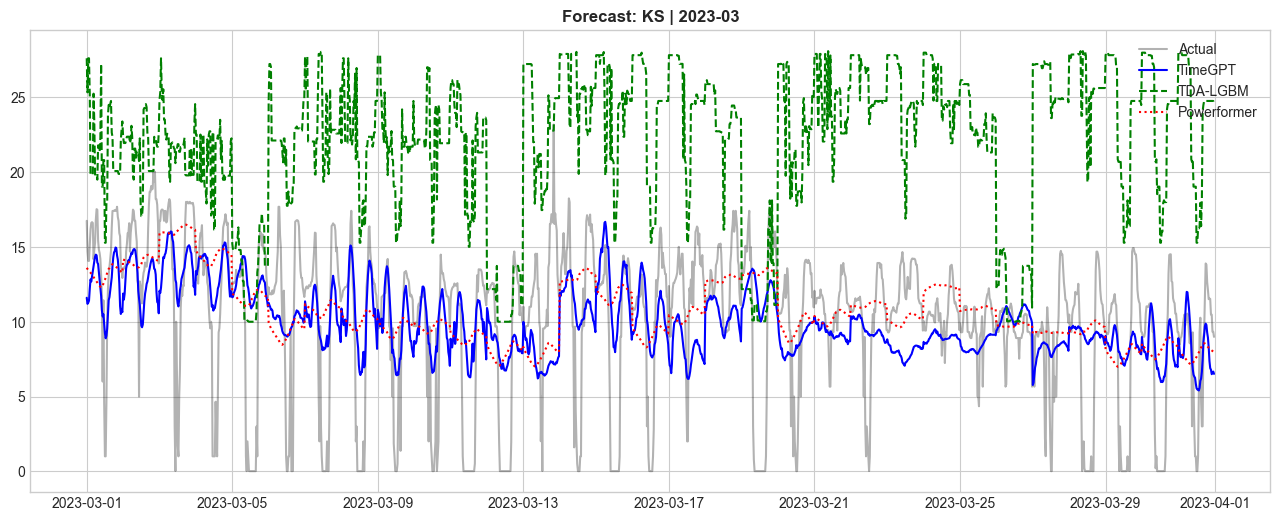

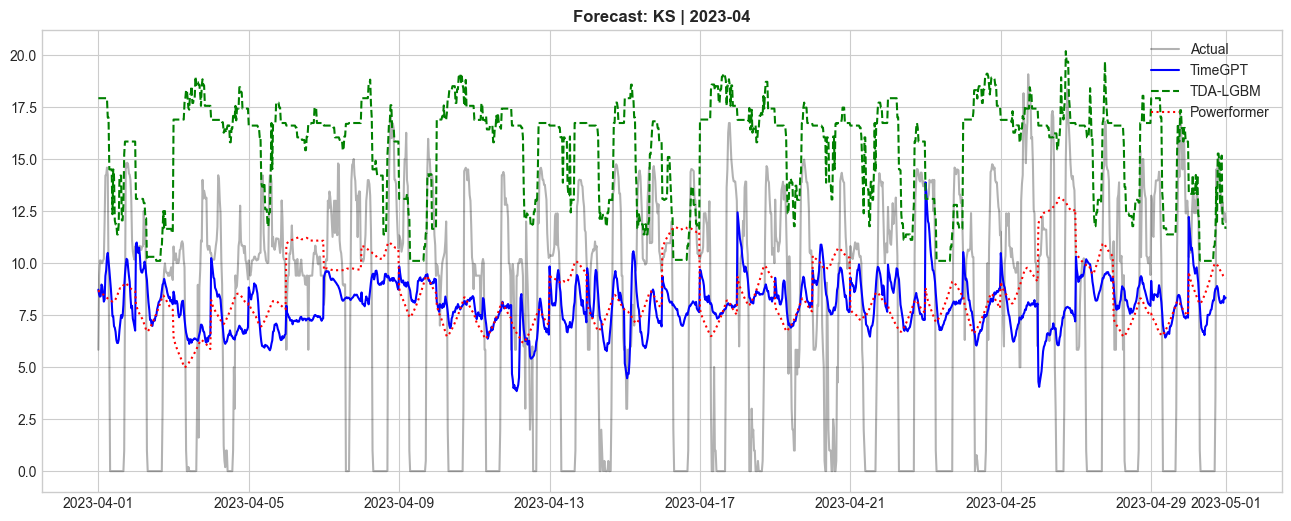

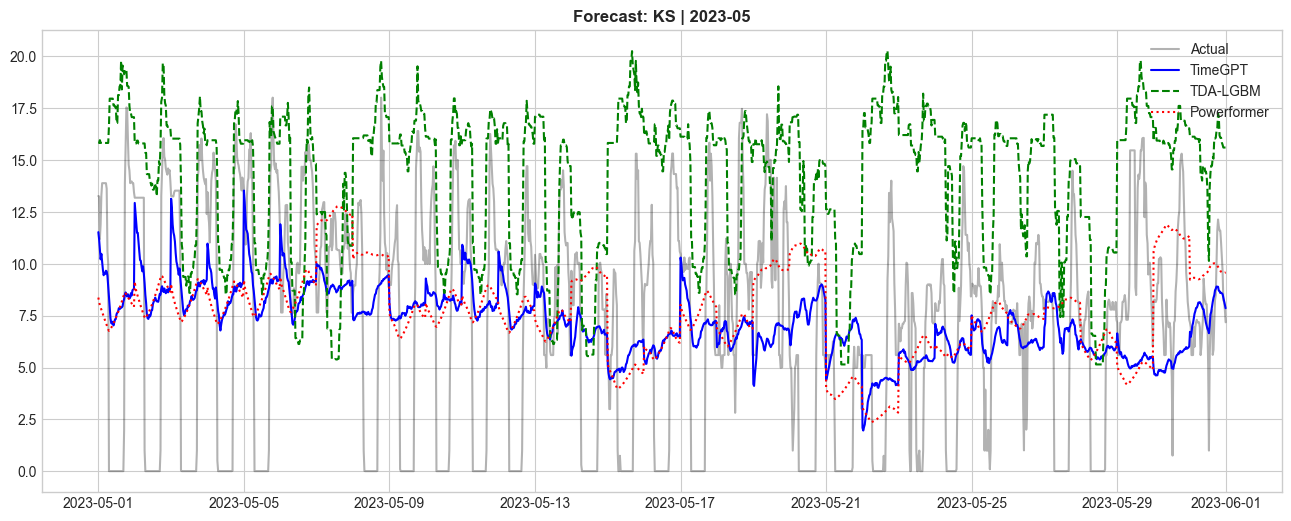

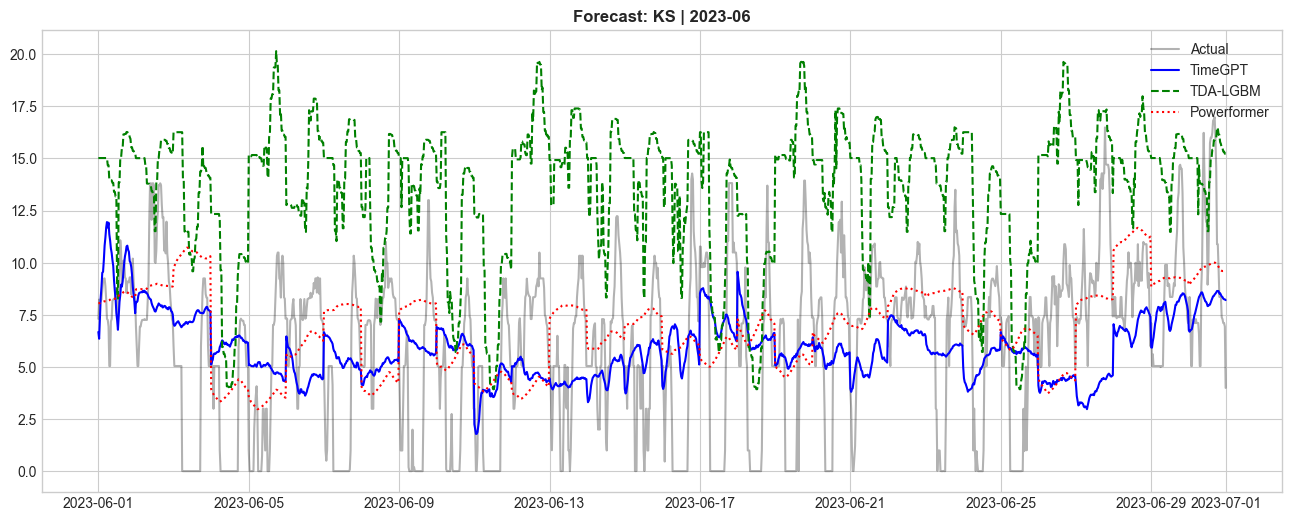

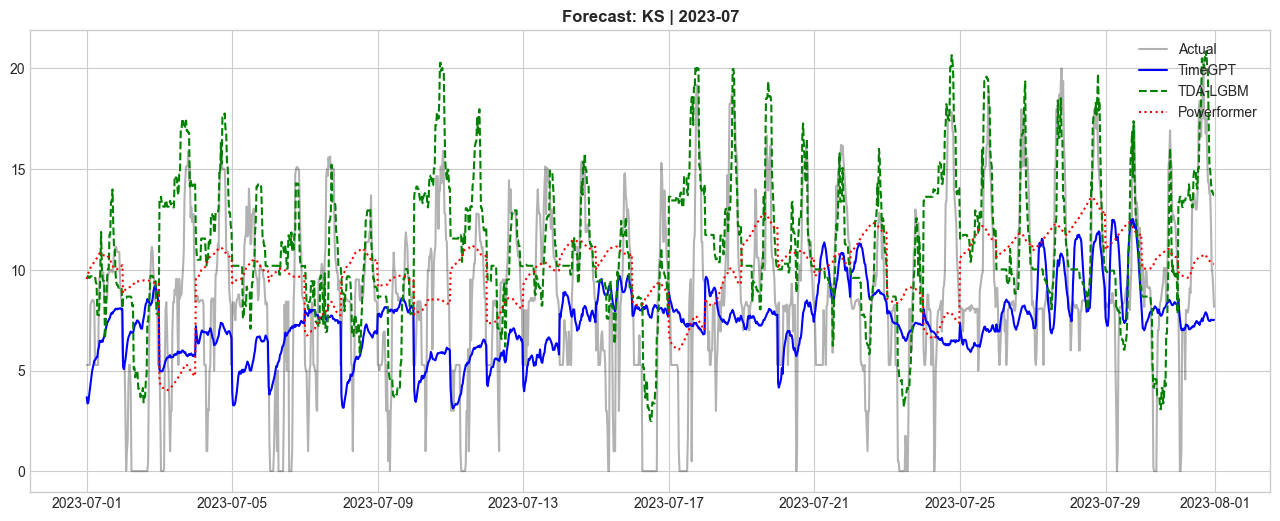

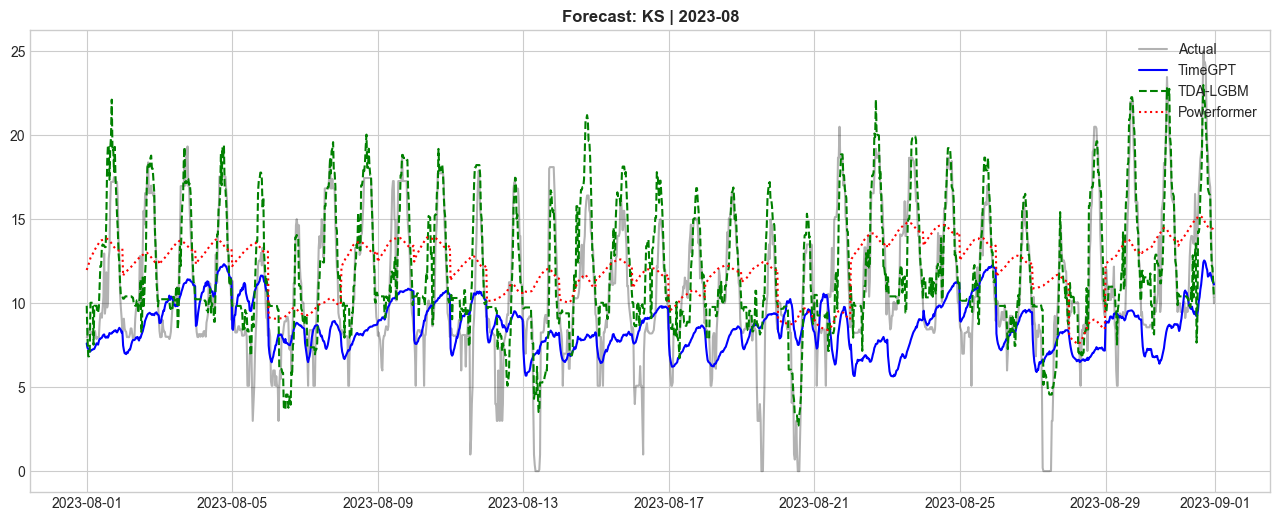

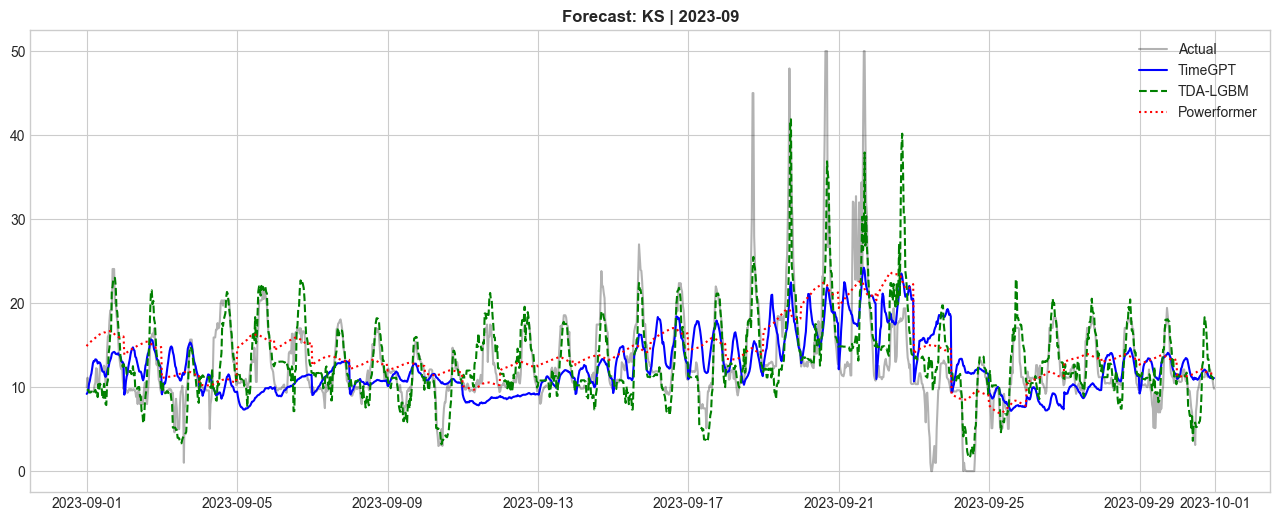

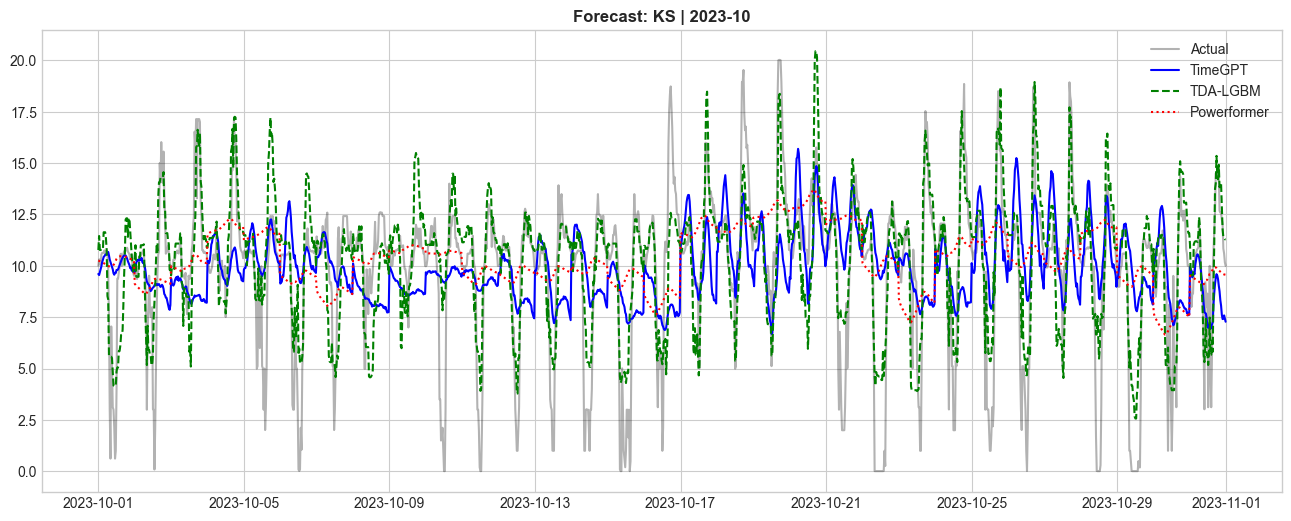

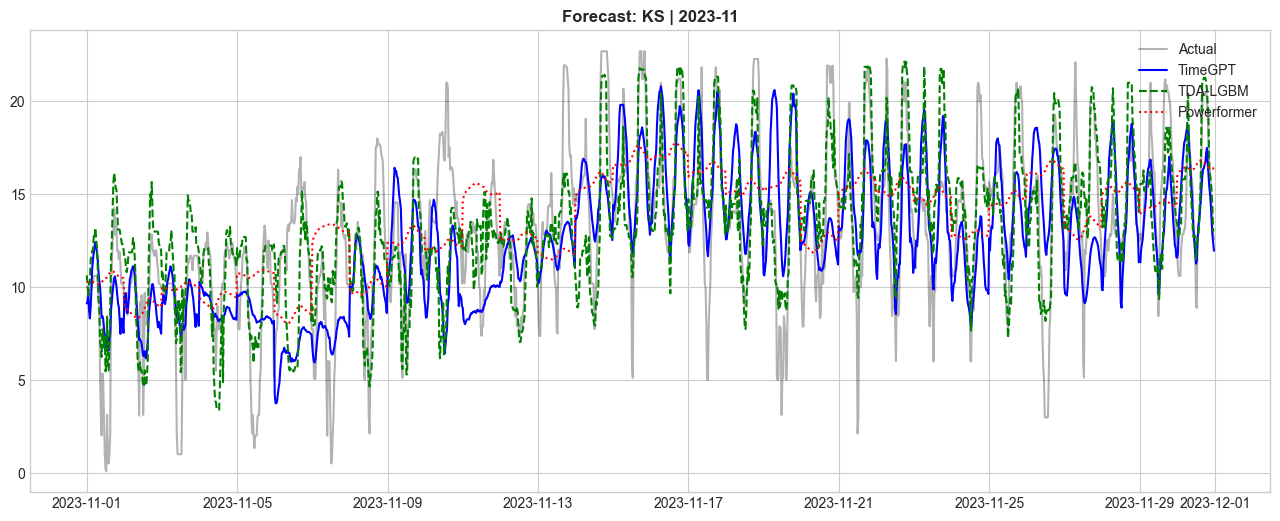

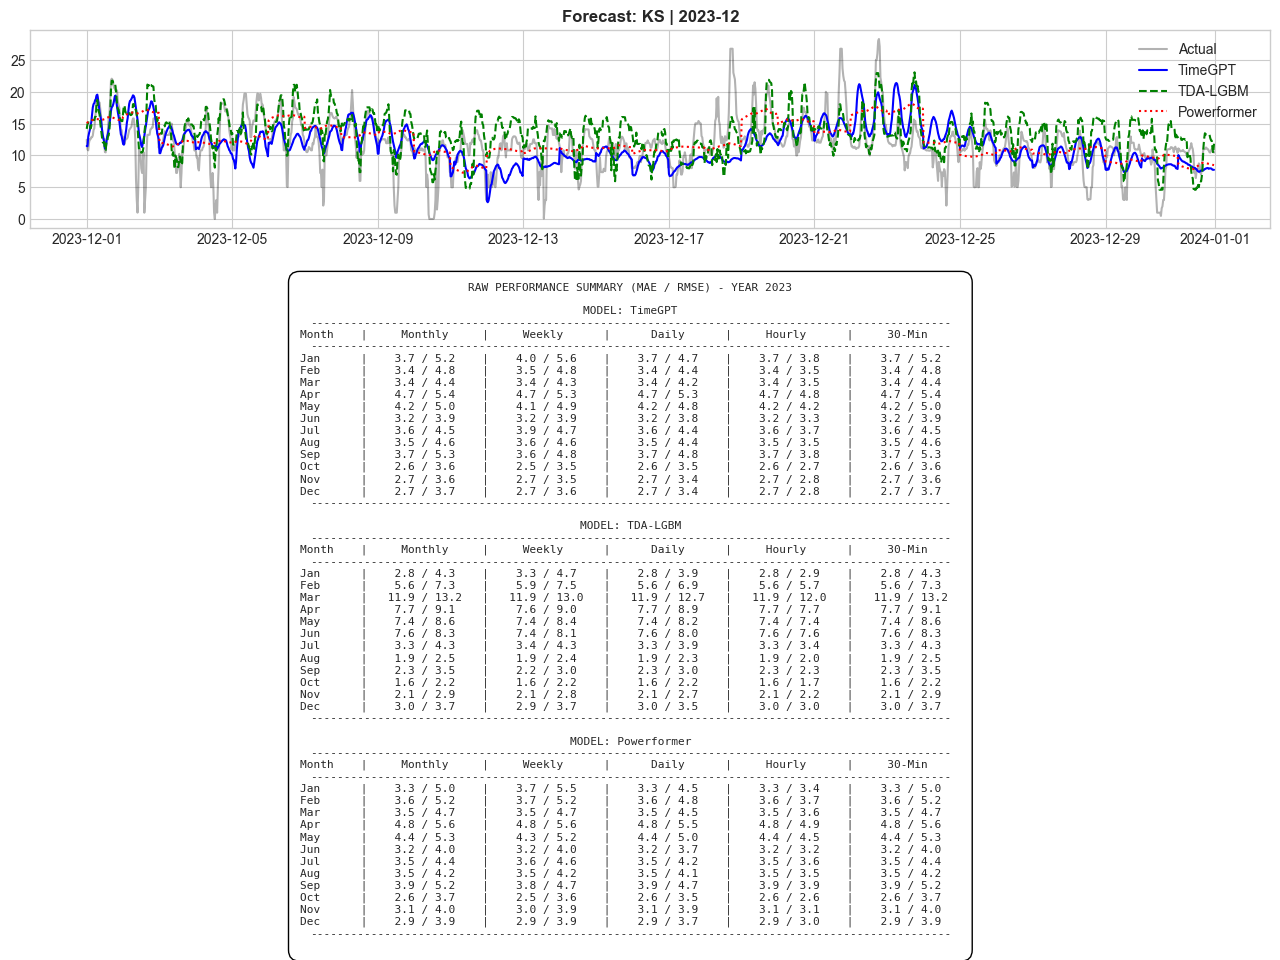

INFO:__main__:Calculating TDA Features for TK...


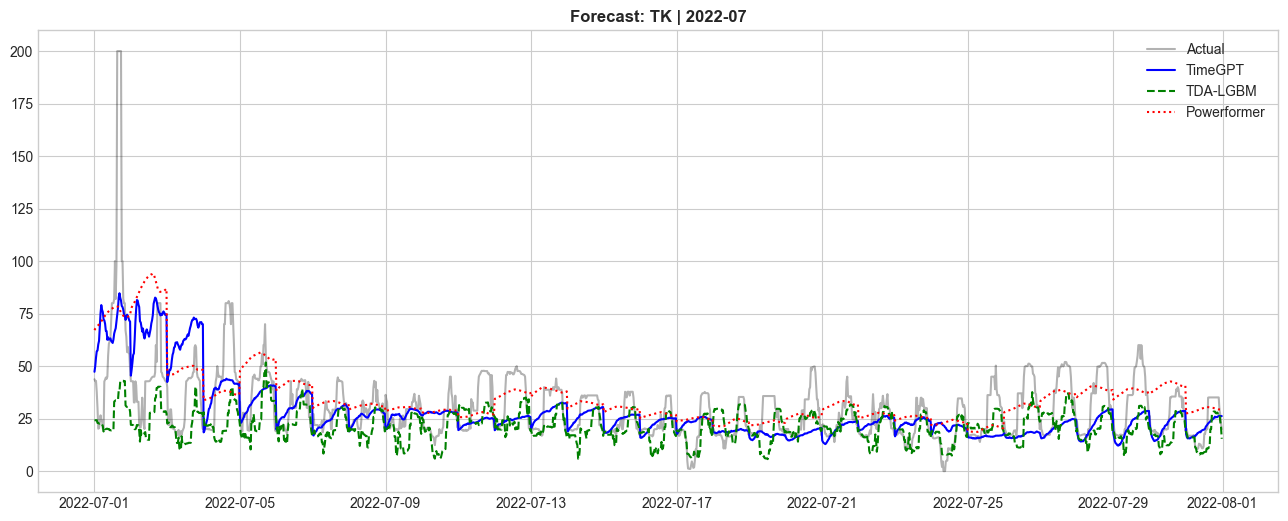

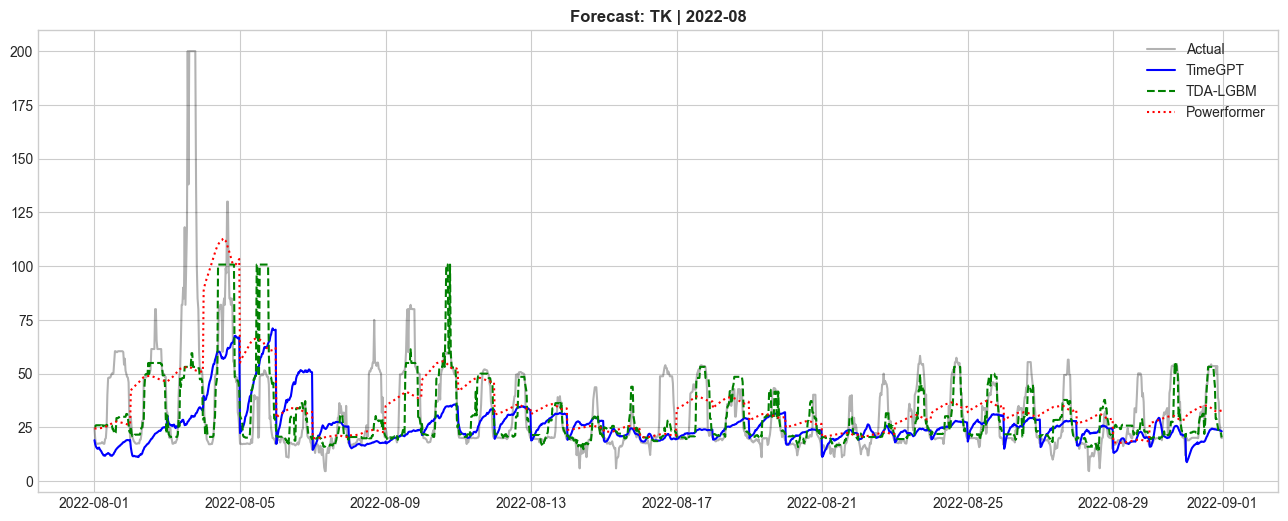

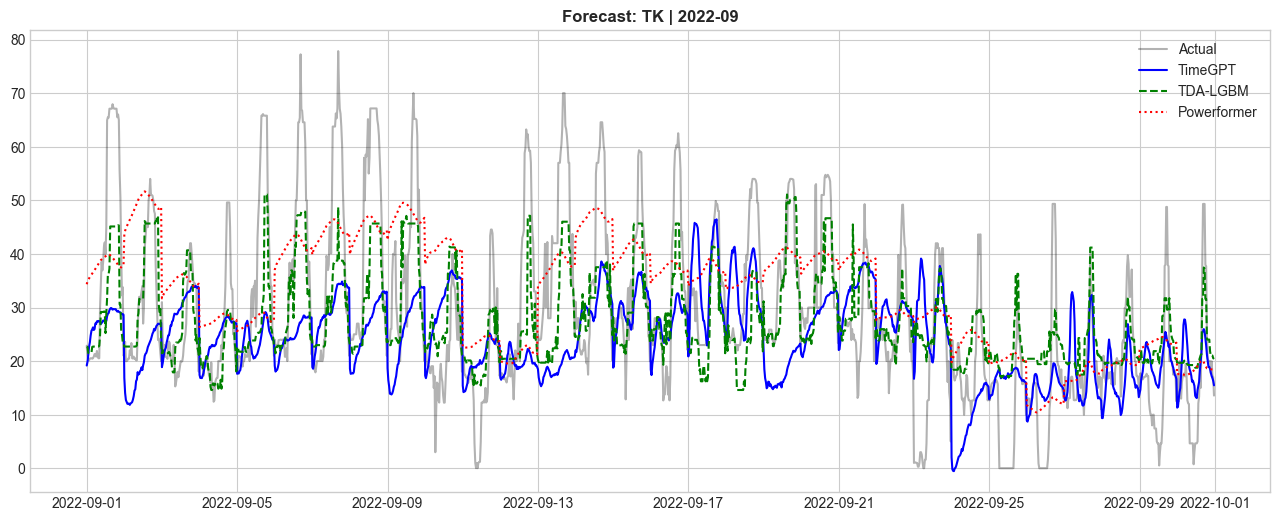

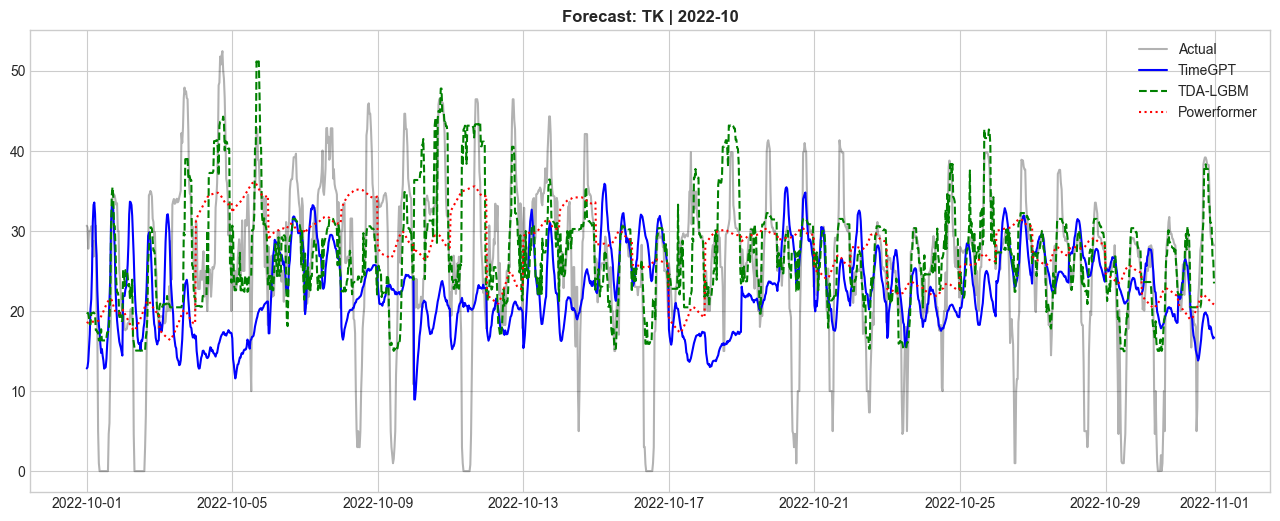

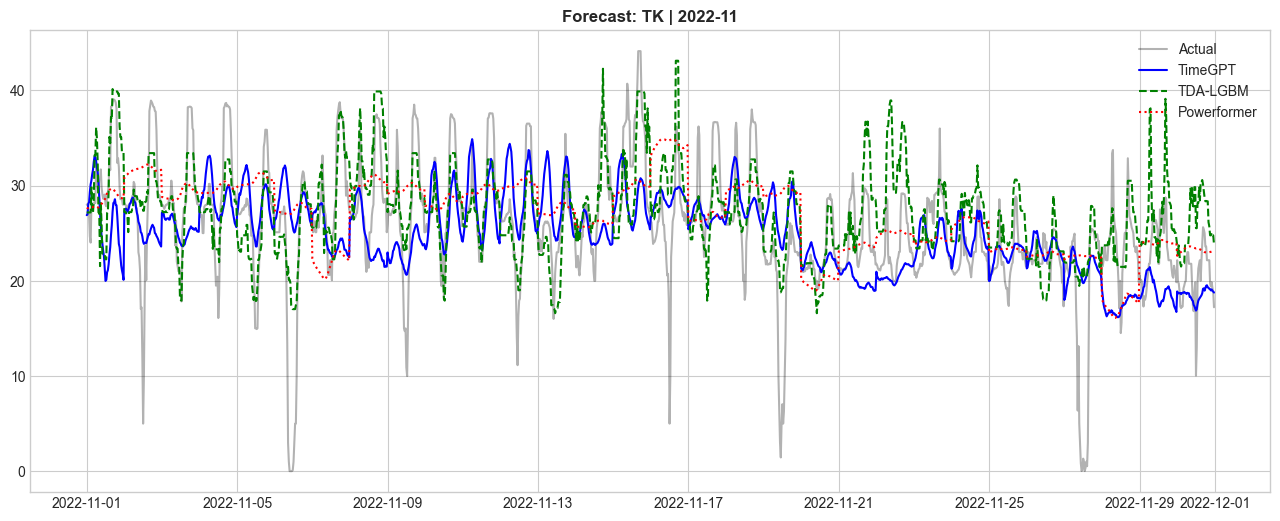

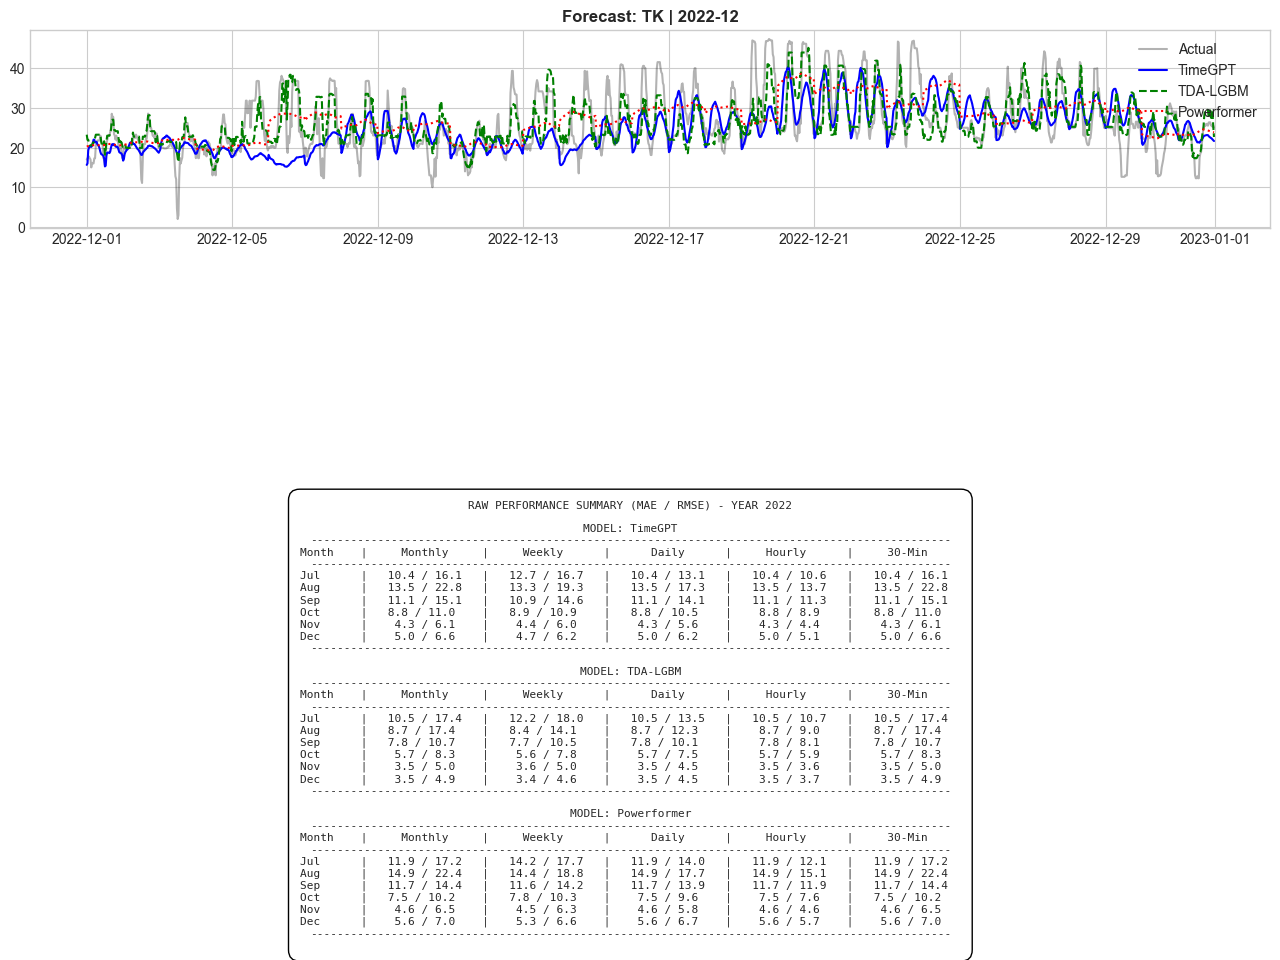

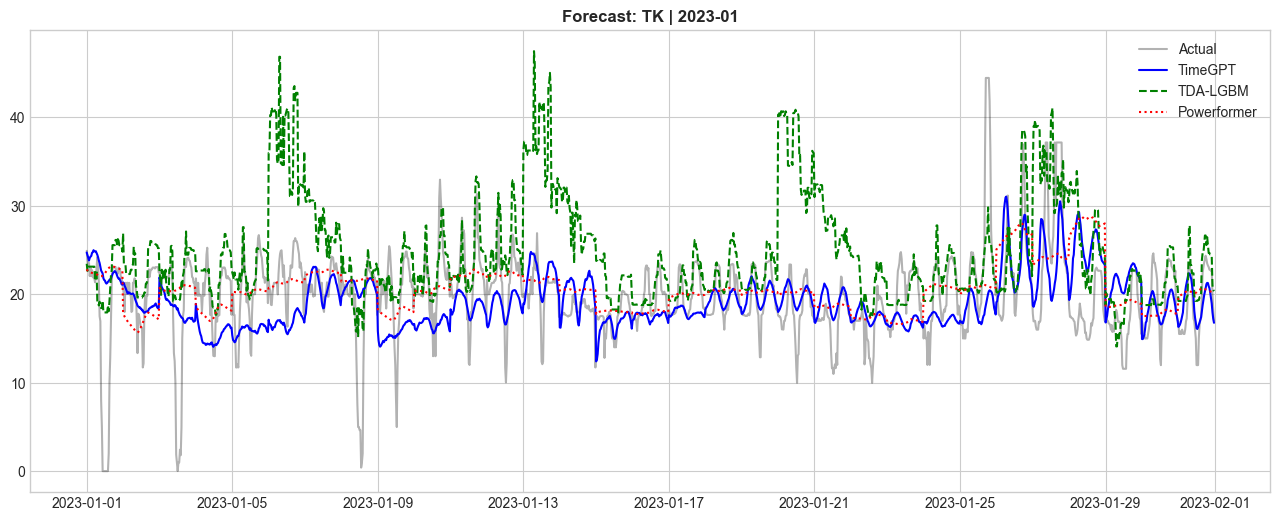

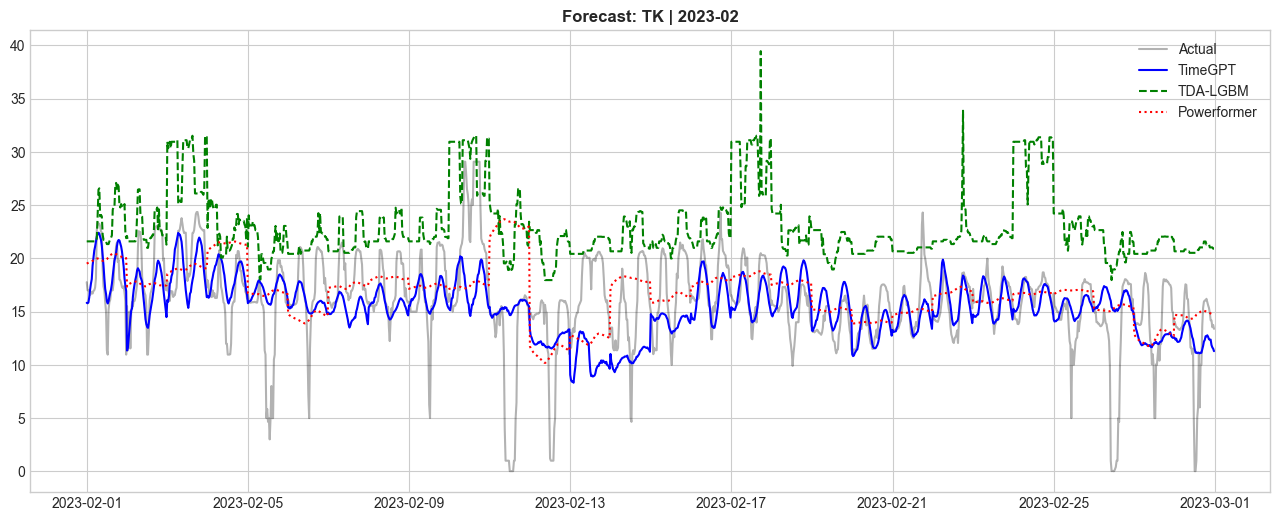

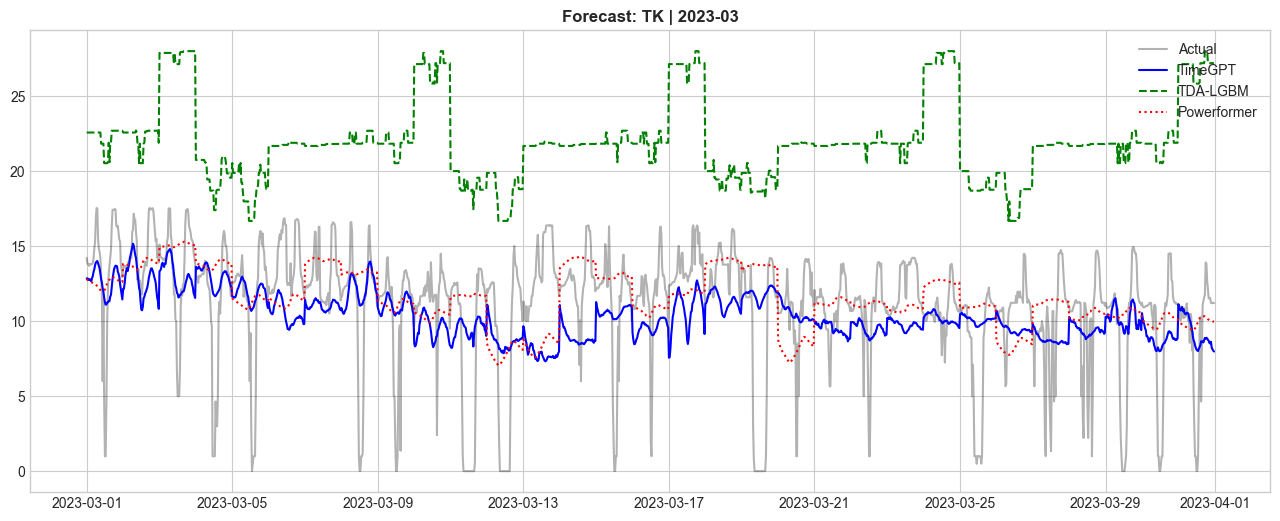

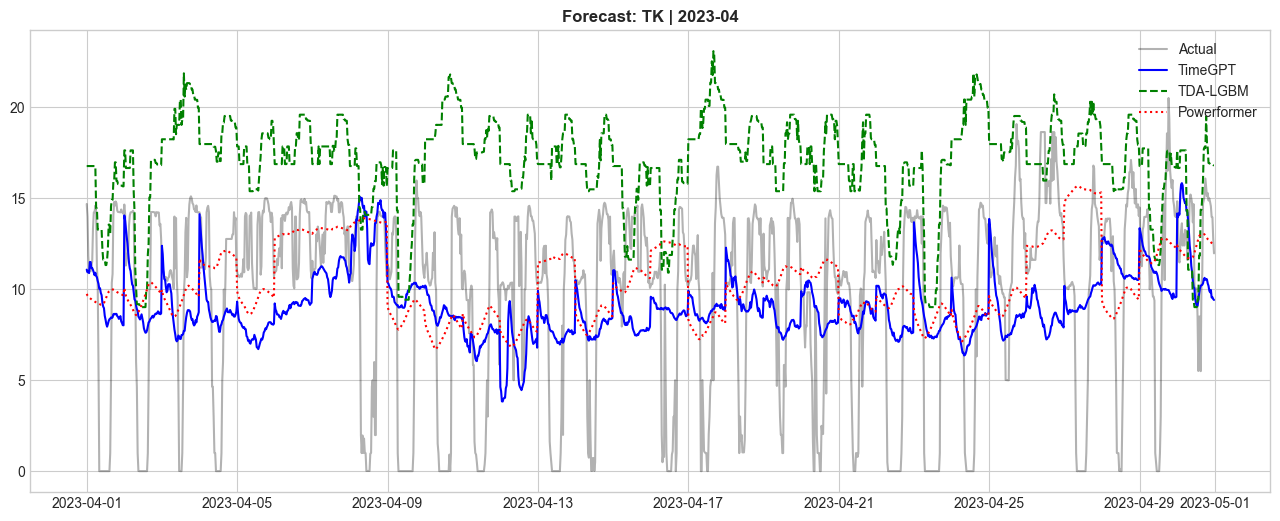

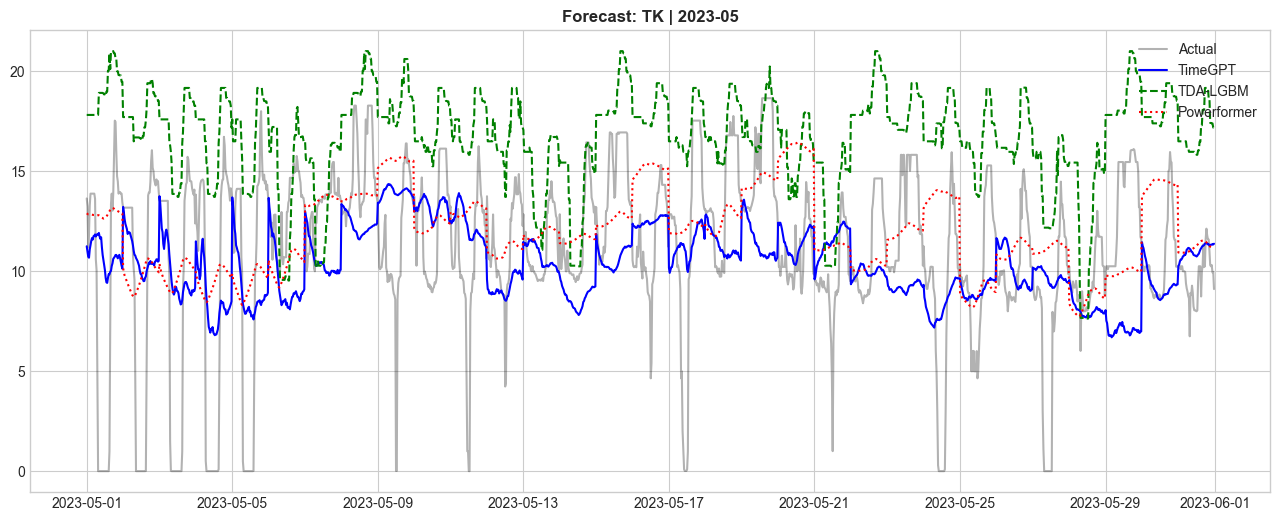

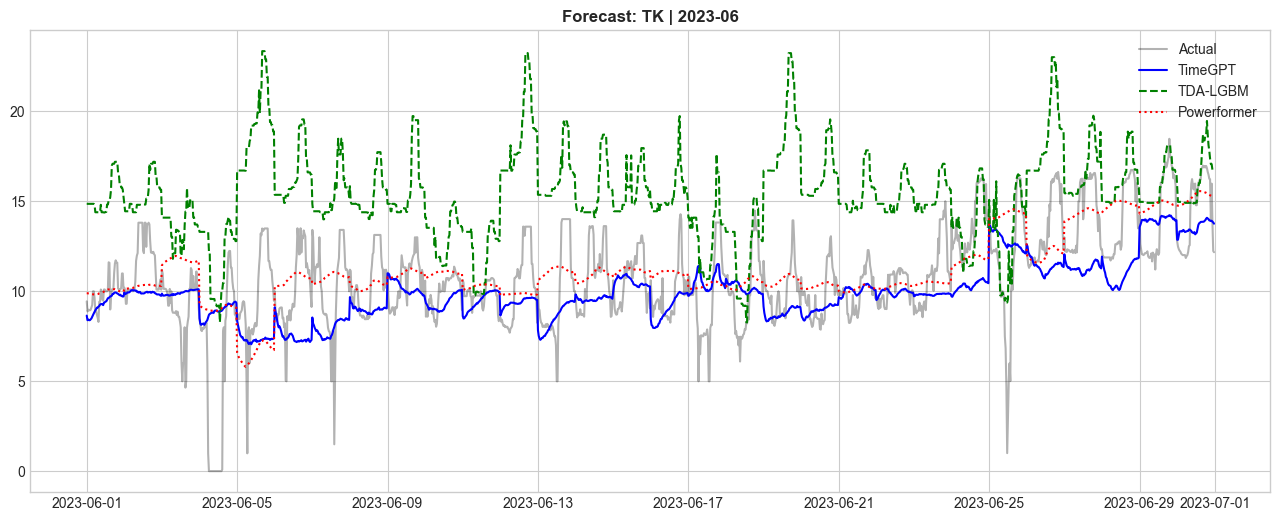

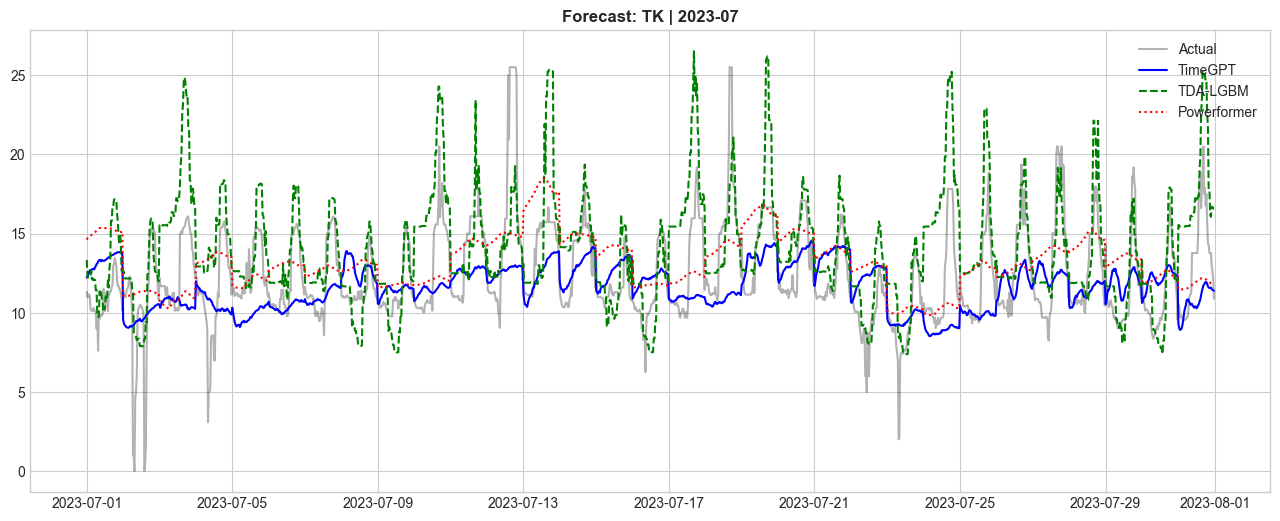

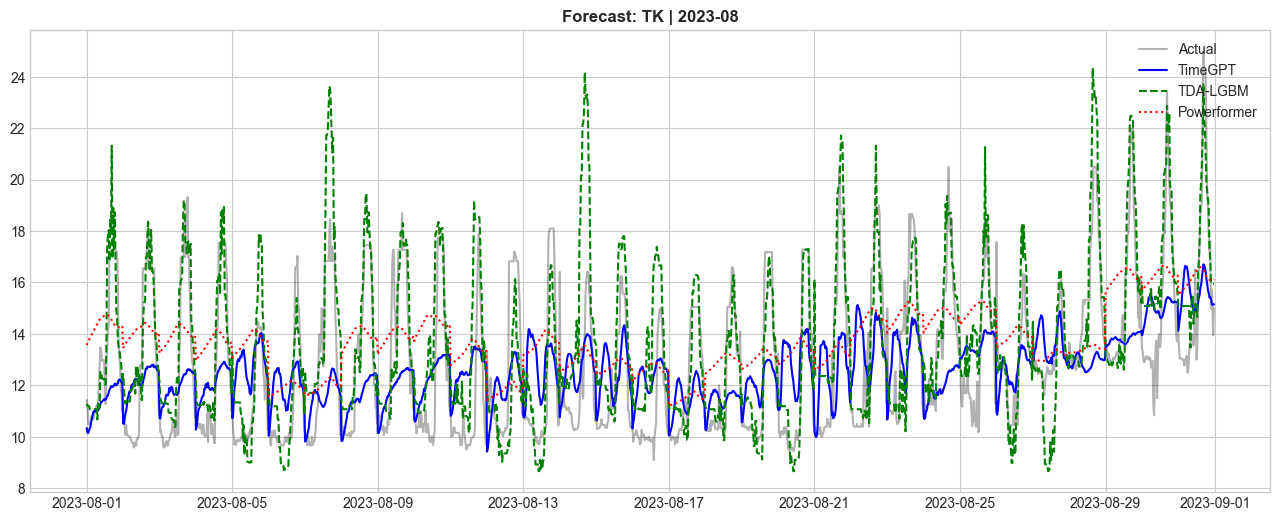

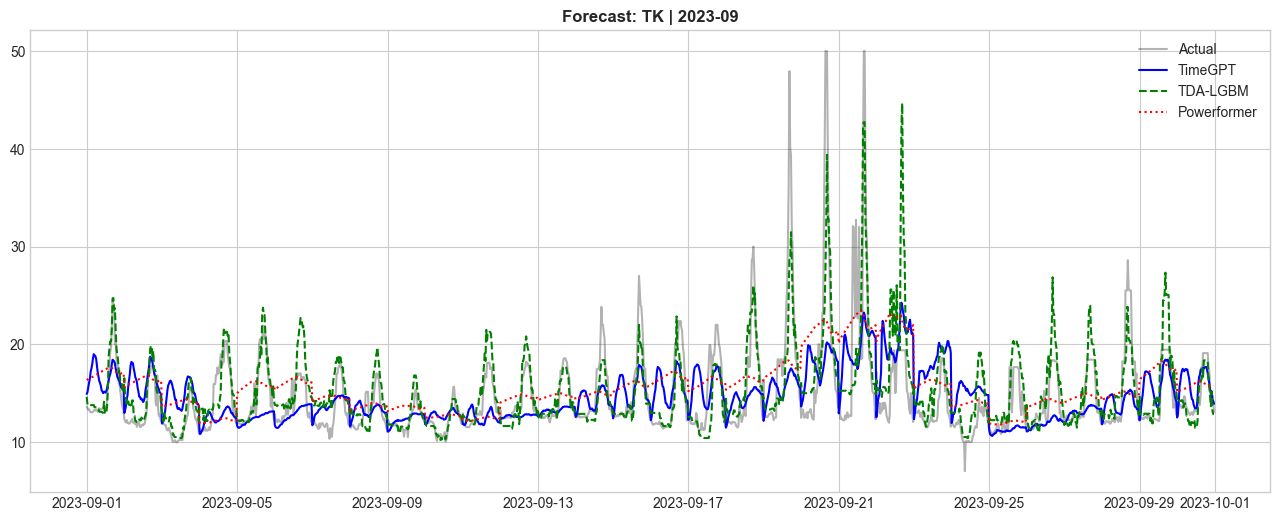

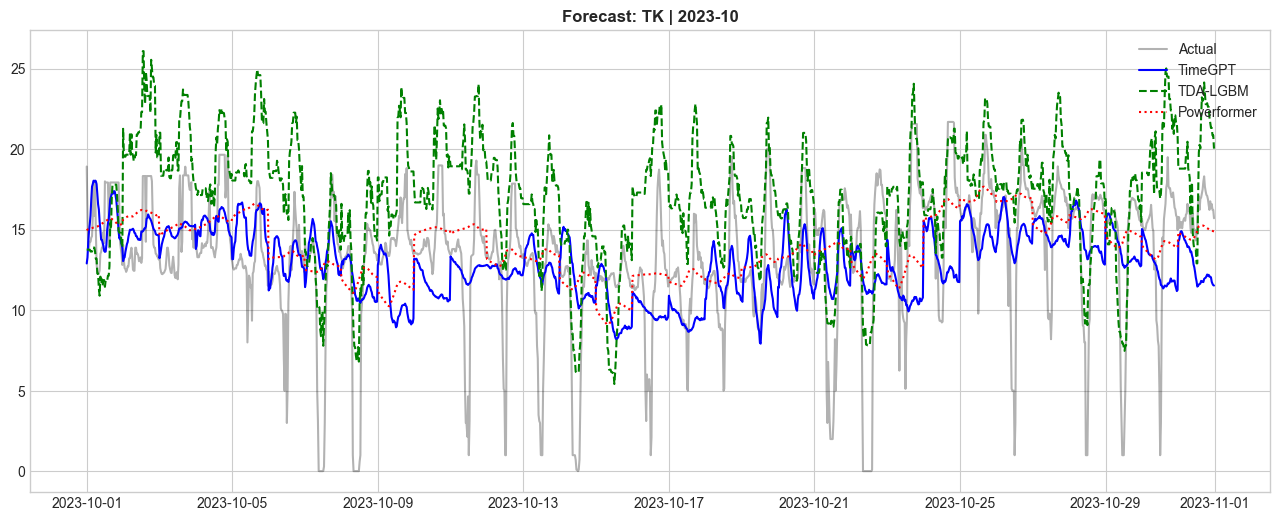

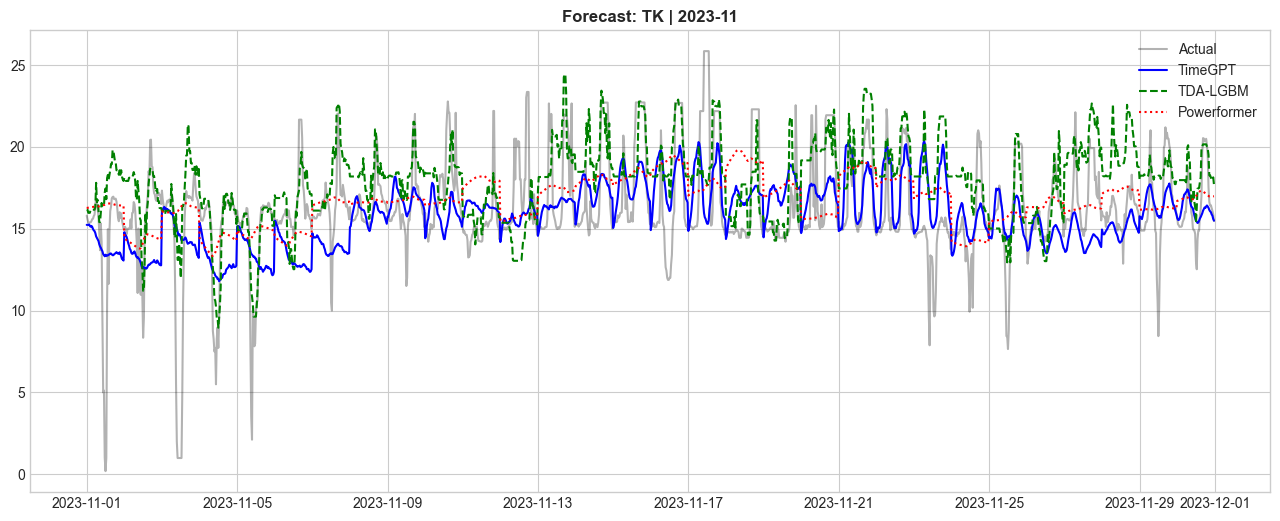

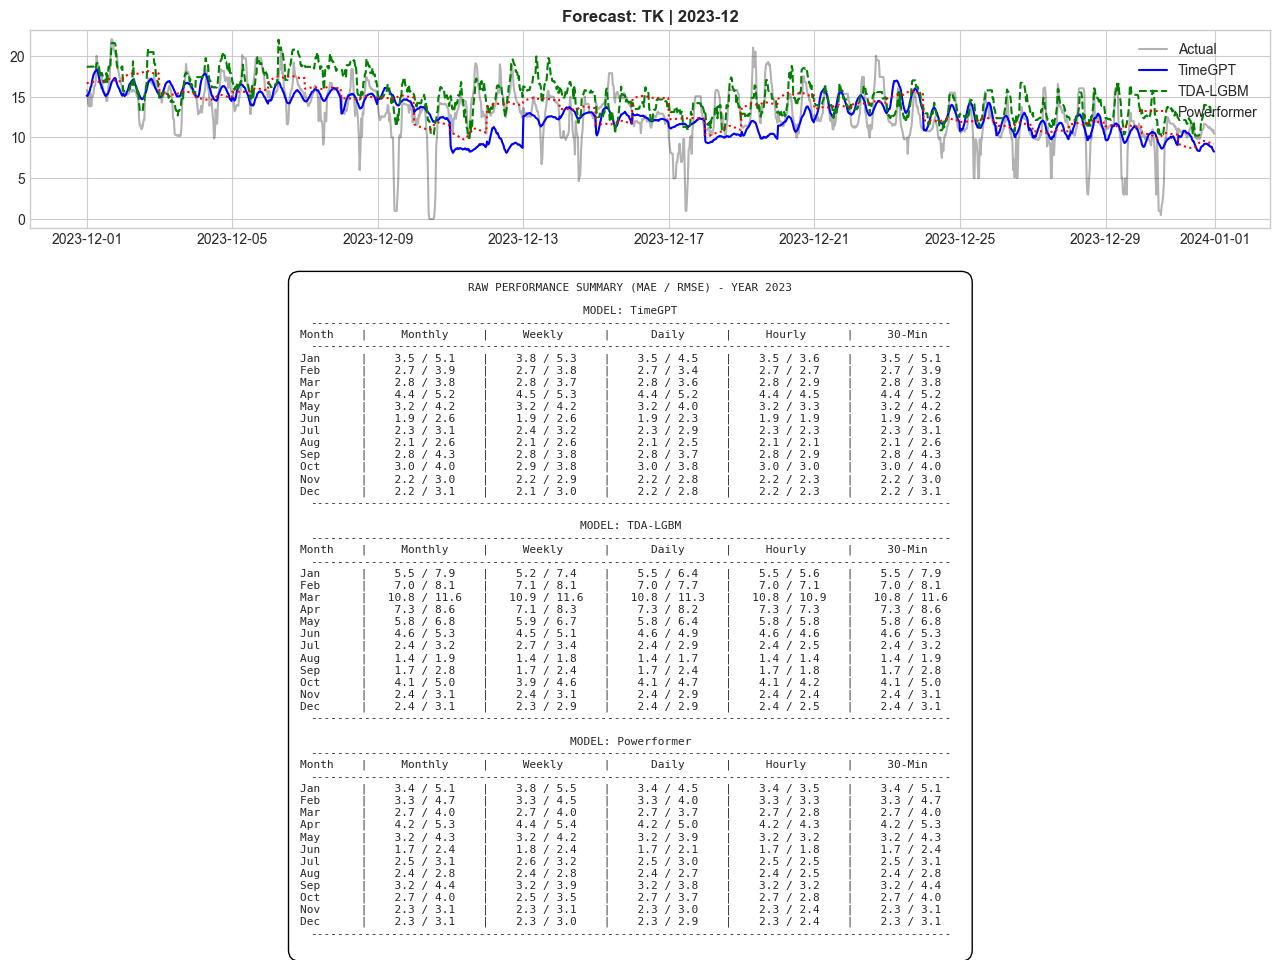

In [ ]:
import os
import time
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb 
from nixtla import NixtlaClient
from dotenv import load_dotenv
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1) การตั้งค่าระบบ ---
BASE_DIR = r"D:\Time-GPT"
ENV_PATH = os.path.join(BASE_DIR, "project", ".env")
SAVE_DIR = os.path.join(BASE_DIR, "research_results")

load_dotenv(ENV_PATH, override=True)
API_KEY = os.getenv("NIXTLA_API_KEY")
nixtla_client = NixtlaClient(api_key=API_KEY)

TIME_COL, VALUE_COL, FREQ = "ds", "y", "30min"
if not os.path.exists(SAVE_DIR): os.makedirs(SAVE_DIR)

plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)
logging.getLogger("nixtla").setLevel(logging.ERROR)

try:
    from gtda.time_series import SlidingWindow
    from gtda.homology import VietorisRipsPersistence
    from gtda.diagrams import PersistenceEntropy
    HAS_TDA = True
except ImportError:
    HAS_TDA = False

CITY_CONFIG = {
    "KS": {"path": os.path.join(BASE_DIR, "dataset", "KS_ready.csv")},
    "TK": {"path": os.path.join(BASE_DIR, "dataset", "TK_ready.csv")}
}

# --- 2) ฟังก์ชันคำนวณสถิติ ---

def powerformer_sliding_window(history, h_len, alpha=0.5):
    if len(history) == 0: return np.zeros(h_len)
    curr_hist = np.array(history)
    predictions = np.zeros(h_len)
    for i in range(h_len):
        dt = np.arange(1, len(curr_hist) + 1)
        weights = np.exp(-alpha * np.log(dt))
        weights /= weights.sum()
        pred_val = np.dot(curr_hist[::-1], weights)
        predictions[i] = pred_val
        curr_hist = np.append(curr_hist[1:], pred_val)
    return predictions

def get_tda_features(data, window=48):
    if not HAS_TDA or len(data) < window: return np.zeros((len(data), 2))
    try:
        sw = SlidingWindow(size=window, stride=1)
        X_sw = sw.fit_transform(data.reshape(-1, 1))
        vr = VietorisRipsPersistence(homology_dimensions=[0, 1]) 
        entropy = PersistenceEntropy().fit_transform(vr.fit_transform(X_sw))
        return np.pad(entropy, ((window-1, 0), (0, 0)), mode='edge')
    except Exception as e: 
        logger.error(f"TDA Error: {e}")
        return np.zeros((len(data), 2))

def get_full_granular_metrics(df_res, model_col):
    """คำนวณ MAE และ RAW RMSE ในแต่ละ time resolution
    
    RAW RMSE: คำนวณ RMSE บน raw 30-min data ภายใน window แต่ละช่วง แล้ว average
    ทำให้ RMSE สะท้อน error จริง ไม่ถูก cancel จากการ average ก่อน
    """
    # [FIX #1] ใช้ copy เพื่อป้องกันการแก้ไข DataFrame ต้นฉบับ
    df_res = df_res.copy()
    df_res[TIME_COL] = pd.to_datetime(df_res[TIME_COL])

    actual = df_res['actual'].values
    pred   = df_res[model_col].values

    def window_raw_rmse_mae(group_keys):
        """คำนวณ RMSE/MAE ภายในแต่ละ window บน raw data แล้ว average across windows"""
        rmse_list, mae_list = [], []
        for _, grp in df_res.groupby(group_keys):
            if len(grp) < 1:
                continue
            a = grp['actual'].values
            p = grp[model_col].values
            rmse_list.append(np.sqrt(np.mean((a - p) ** 2)))
            mae_list.append(np.mean(np.abs(a - p)))
        if not rmse_list:
            return np.nan, np.nan
        return float(np.mean(mae_list)), float(np.mean(rmse_list))

    # 5. 30-Min — Raw data โดยตรง (baseline)
    m30_mae  = float(np.mean(np.abs(actual - pred)))
    m30_rmse = float(np.sqrt(np.mean((actual - pred) ** 2)))

    # 4. Hourly — RAW RMSE/MAE ภายในแต่ละชั่วโมง
    h_mae, h_rmse = window_raw_rmse_mae(df_res[TIME_COL].dt.floor('h'))

    # 3. Daily — RAW RMSE/MAE ภายในแต่ละวัน
    d_mae, d_rmse = window_raw_rmse_mae(df_res[TIME_COL].dt.floor('D'))

    # 2. Weekly — RAW RMSE/MAE ภายในแต่ละสัปดาห์ (ISO week)
    iso = df_res[TIME_COL].dt.isocalendar()
    week_key = iso['year'].astype(str) + '_W' + iso['week'].astype(str).str.zfill(2)
    w_mae, w_rmse = window_raw_rmse_mae(week_key)

    # 1. Monthly — RAW RMSE/MAE ภายในเดือนนี้ (= 30-Min เพราะ full_res คือ 1 เดือน)
    #    [FIX #2] ไม่ groupby อีก เพราะได้ 1 กลุ่ม → ใช้ค่า 30-min โดยตรง
    m_mae  = m30_mae
    m_rmse = m30_rmse

    return {
        'MAE':  [m_mae,  w_mae,  d_mae,  h_mae,  m30_mae],
        'RMSE': [m_rmse, w_rmse, d_rmse, h_rmse, m30_rmse]
    }

# --- 3) วงจรการวิจัย ---

def run_research_v24(city_id):
    cfg = CITY_CONFIG[city_id]
    df = pd.read_csv(cfg['path'])
    df[TIME_COL] = pd.to_datetime(df["DATETIME"])
    df[VALUE_COL] = pd.to_numeric(df["y"], errors="coerce")
    df = df.sort_values(TIME_COL).ffill().bfill()
    
    # -----------------------------------------------------------------
    # สร้าง Features สำหรับ Fair Day-Ahead Forecasting (ไร้ Data Leakage)
    # -----------------------------------------------------------------
    df["hour"] = df[TIME_COL].dt.hour
    df["dayofweek"] = df[TIME_COL].dt.dayofweek
    df["month"] = df[TIME_COL].dt.month
    
    # SHIFT ข้อมูลในอดีตไป 48 steps (24 ชั่วโมง) เพื่อรับประกันว่า LGBM ไม่เห็นข้อมูลของวันนี้
    df["lag_48"] = df[VALUE_COL].shift(48)
    df["lag_336"] = df[VALUE_COL].shift(336)
    
    # คำนวณ rolling mean 48 step จากค่าที่ถูก shift ไปแล้ว (ของเมื่อวาน)
    df["roll_mean_48"] = df["lag_48"].rolling(window=48).mean()
    
    if "tda_h0" not in df.columns:
        logger.info(f"Calculating TDA Features for {city_id}...")
        tda_feats = get_tda_features(df[VALUE_COL].values)
        # นำค่า TDA entropy ของเมื่อวาน มาเป็น Feature ของวันนี้
        df["tda_h0"] = pd.Series(tda_feats[:, 0], index=df.index).shift(48)
        df["tda_h1"] = pd.Series(tda_feats[:, 1], index=df.index).shift(48)
        
    # เติมค่า NaN ที่เกิดจากการ Shift ในช่วงแรกด้วยค่าแถวถัดไป (Backfill) เฉพาะเพื่อให้โมเดลทำงานได้
    df[VALUE_COL] = df[VALUE_COL].ffill().bfill()

    feature_cols = ["hour", "dayofweek", "month", "lag_48", "lag_336", "roll_mean_48", "tda_h0", "tda_h1"]

    # -----------------------------------------------------------------
    # เริ่มต้นรอบการวิจัย (เริ่มประเมินที่ เดือน 7 ปี 2022)
    # -----------------------------------------------------------------
    train_start_date = pd.Timestamp(2022, 3, 1) # บังคับเริ่มเทรนที่เดือน 3 ปี 2022

    for year in [2022, 2023]:
        annual_stats = [] 

        for month in range(1, 13):
            start_m = pd.Timestamp(year, month, 1)
            
            # บังคับให้เริ่มประเมิน (Testing) ที่เดือน 7 ปี 2022 เป็นต้นไป
            if year == 2022 and month < 7: 
                continue 
                
            if start_m > df[TIME_COL].max(): 
                continue
            
            checkpoint_file = os.path.join(SAVE_DIR, f"{city_id}_{year}_{month:02d}.csv")
            
            if os.path.exists(checkpoint_file):
                full_res = pd.read_csv(checkpoint_file)
                full_res[TIME_COL] = pd.to_datetime(full_res[TIME_COL])
            else:
                # ข้อมูลเทรนเริ่มตั้งแต่ เดือน 3 ปี 2022 จนถึง ก่อนเดือนที่กำลังจะประเมิน
                train_mask = (df[TIME_COL] >= train_start_date) & (df[TIME_COL] < start_m)
                train_data = df[train_mask].dropna()
                
                # เพิ่ม Early Stopping ลด Overfitting ให้ LightGBM (ยุติธรรมมากขึ้น)
                split_idx = int(len(train_data) * 0.8)
                X_train, y_train = train_data[feature_cols].iloc[:split_idx], train_data[VALUE_COL].iloc[:split_idx]
                X_val, y_val = train_data[feature_cols].iloc[split_idx:], train_data[VALUE_COL].iloc[split_idx:]
                
                lgbm_model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.03, random_state=42, verbosity=-1)
                lgbm_model.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
                )
                
                results_list = []
                for day in pd.date_range(start_m, start_m + pd.offsets.MonthEnd(1), freq='D'):
                    day_mask = (df[TIME_COL] >= day) & (df[TIME_COL] < day + pd.Timedelta(days=1))
                    actual_day = df[day_mask]
                    
                    if actual_day.empty: continue
                    # ข้อมูลประวัติที่จะส่งให้ TimeGPT และ Powerformer (ไม่มีข้อมูลของวันนี้)
                    hist = df[df[TIME_COL] < day].tail(1500)[[TIME_COL, VALUE_COL]]
                    
                    try:
                        gpt_res = nixtla_client.forecast(hist, h=len(actual_day), freq=FREQ)
                        gpt_day = gpt_res['TimeGPT'].values
                    except Exception as e:
                        logger.error(f"TimeGPT API Failed on {day.date()}: {e}")
                        last_val = hist[VALUE_COL].iloc[-1] if not hist.empty else 0
                        gpt_day = np.full(len(actual_day), last_val)
                    
                    # LGBM ทำนายวันนี้ โดยที่ feature_cols ทั้งหมดเป็นข้อมูลที่ถูก shift มาแล้ว (Day-ahead)
                    lgbm_day = lgbm_model.predict(actual_day[feature_cols])
                    
                    # Powerformer ทำนายโดยรับ history 48 step ล่าสุด
                    pwr_day = powerformer_sliding_window(df[df[TIME_COL] < day][VALUE_COL].tail(48).values, len(actual_day))
                    
                    results_list.append(pd.DataFrame({
                        TIME_COL: actual_day[TIME_COL], 
                        'actual': actual_day[VALUE_COL].values, 
                        'gpt': gpt_day, 
                        'lgbm': lgbm_day, 
                        'pwr': pwr_day
                    }))
                    
                if not results_list:
                    logger.warning(f"No results for {city_id} {year}-{month:02d}, skipping.")
                    continue
                full_res = pd.concat(results_list, ignore_index=True)
                full_res.to_csv(checkpoint_file, index=False)

            # ประเมินผล
            m_stats = {m: get_full_granular_metrics(full_res, c) for m, c in zip(['TimeGPT', 'TDA-LGBM', 'Powerformer'], ['gpt', 'lgbm', 'pwr'])}
            annual_stats.append({'month_name': start_m.strftime('%b'), 'stats': m_stats})

            # --- PLOTTING ---
            fig, ax = plt.subplots(figsize=(16, 6))
            ax.plot(full_res[TIME_COL], full_res['actual'], color='black', alpha=0.3, label='Actual')
            ax.plot(full_res[TIME_COL], full_res['gpt'], color='blue', label='TimeGPT')
            ax.plot(full_res[TIME_COL], full_res['lgbm'], color='green', linestyle='--', label='TDA-LGBM')
            ax.plot(full_res[TIME_COL], full_res['pwr'], color='red', linestyle=':', label='Powerformer')
            ax.set_title(f"Forecast: {city_id} | {year}-{month:02d}", fontsize=12, fontweight='bold')
            ax.legend(loc='upper right')

            # หากถึงเดือนสุดท้ายของปีนั้น ให้แสดงตารางสรุปผล
            is_last = (month == 12 or start_m + pd.offsets.MonthEnd(1) > df[TIME_COL].max())
            if is_last:
                final_table = f"RAW PERFORMANCE SUMMARY (MAE / RMSE) - YEAR {year}\n"
                header = f"{'Month':<8} | {'Monthly':^15} | {'Weekly':^15} | {'Daily':^15} | {'Hourly':^15} | {'30-Min':^15}\n"
                divider = "-" * 95 + "\n"
                
                table_str = ""
                for model in ['TimeGPT', 'TDA-LGBM', 'Powerformer']:
                    model_box = f"\nMODEL: {model}\n" + divider + header + divider
                    for entry in annual_stats:
                        mae = entry['stats'][model]['MAE']
                        rmse = entry['stats'][model]['RMSE']
                        
                        m_str = f"{mae[0]:.1f} / {rmse[0]:.1f}"
                        w_str = f"{mae[1]:.1f} / {rmse[1]:.1f}"
                        d_str = f"{mae[2]:.1f} / {rmse[2]:.1f}"
                        h_str = f"{mae[3]:.1f} / {rmse[3]:.1f}"
                        m30_str = f"{mae[4]:.1f} / {rmse[4]:.1f}"
                        
                        model_box += f"{entry['month_name']:<8} | {m_str:^15} | {w_str:^15} | {d_str:^15} | {h_str:^15} | {m30_str:^15}\n"
                    table_str += model_box + divider
                
                plt.figtext(0.5, -0.65, final_table + table_str, ha="center", family='monospace', fontsize=8, bbox={"facecolor":"white", "boxstyle":"round,pad=1"})
                plt.subplots_adjust(bottom=0.55)

            plt.show()
            plt.close()

if __name__ == "__main__":
    run_research_v24("KS")
    run_research_v24("TK")